# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures , StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# cleaning Data

In [ ]:
df = pd.read_csv('/content/sample_data/manufacturing.csv')

df.head(10)

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
5,229.178823,8.498306,1947.631786,53136.690654,1.203707e+07,99.998786
6,187.517442,19.412851,3640.248155,42478.694500,6.593260e+06,100.000000
7,278.354600,7.070944,1968.229758,77834.818230,2.156722e+07,95.732723
8,292.732552,20.432896,5981.373734,94223.147069,2.508452e+07,64.623599
9,176.688304,14.145782,2499.394266,34049.372335,5.515789e+06,100.000000


## Check null/Nan

In [ ]:
df.isna().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


In [ ]:
df.columns

Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric',
       'Quality Rating'],
      dtype='object')

In [ ]:
(df==0).any().any()

np.False_

# View the relations

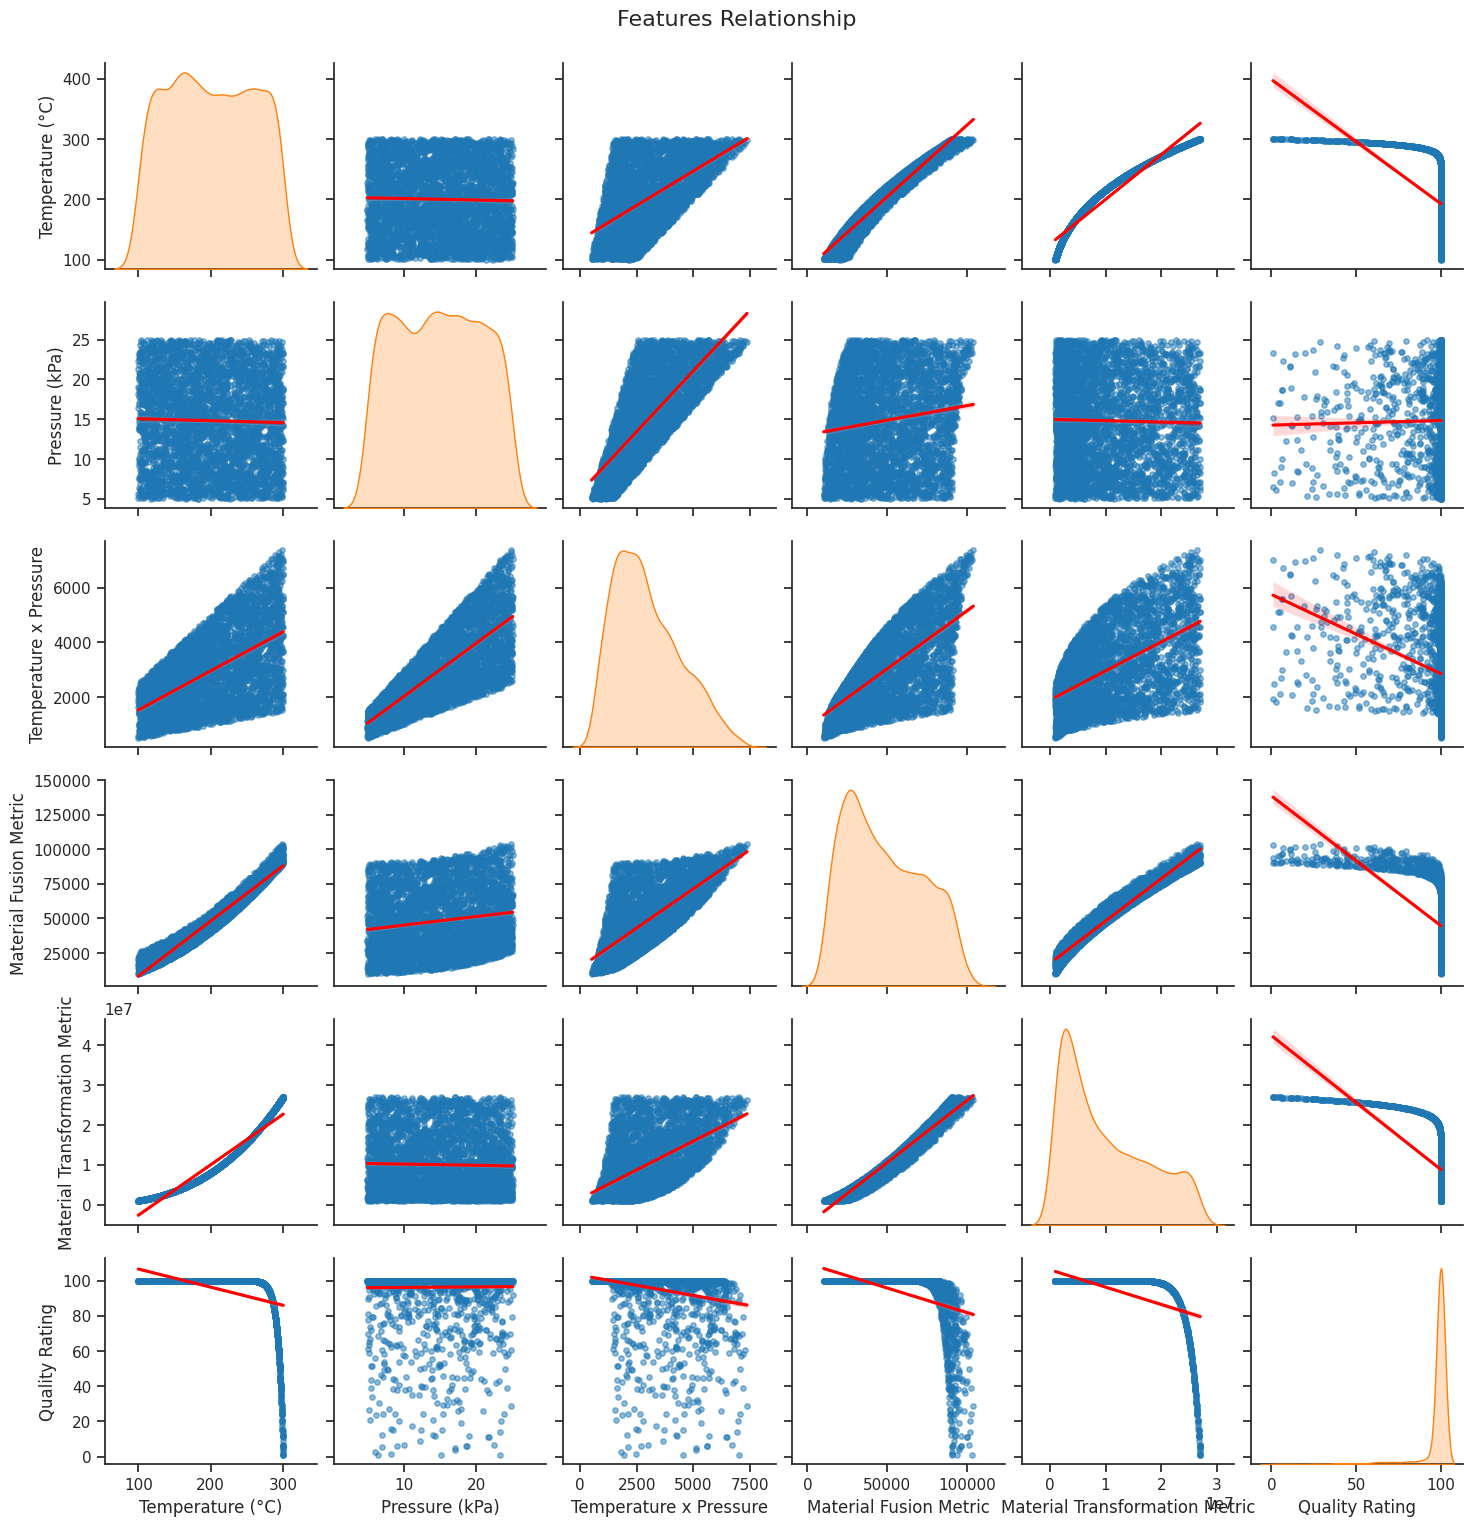

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "Temperature (°C)",
    "Pressure (kPa)",
    "Temperature x Pressure",
    "Material Fusion Metric",
    "Material Transformation Metric",
    "Quality Rating",
]

sns.set_theme(style="ticks")

pair_plot = sns.pairplot(
    df[features],
    kind="reg",
    diag_kind="kde",
    # Pass scatter point styling inside 'scatter_kws'
    plot_kws={
        "scatter_kws": {
            "alpha": 0.5,
            "s": 15,
        },
        "line_kws": {
            "color": "red",
        },  # Optional: Colors the trendlines red to stand out
        "color": "#1f77b4",  # Colors the scatter points
    },
    diag_kws={"color": "#ff7f0e"},
)

pair_plot.fig.suptitle("Features Relationship", y=1.02, fontsize=16)

plt.show()


 > Simple Findings
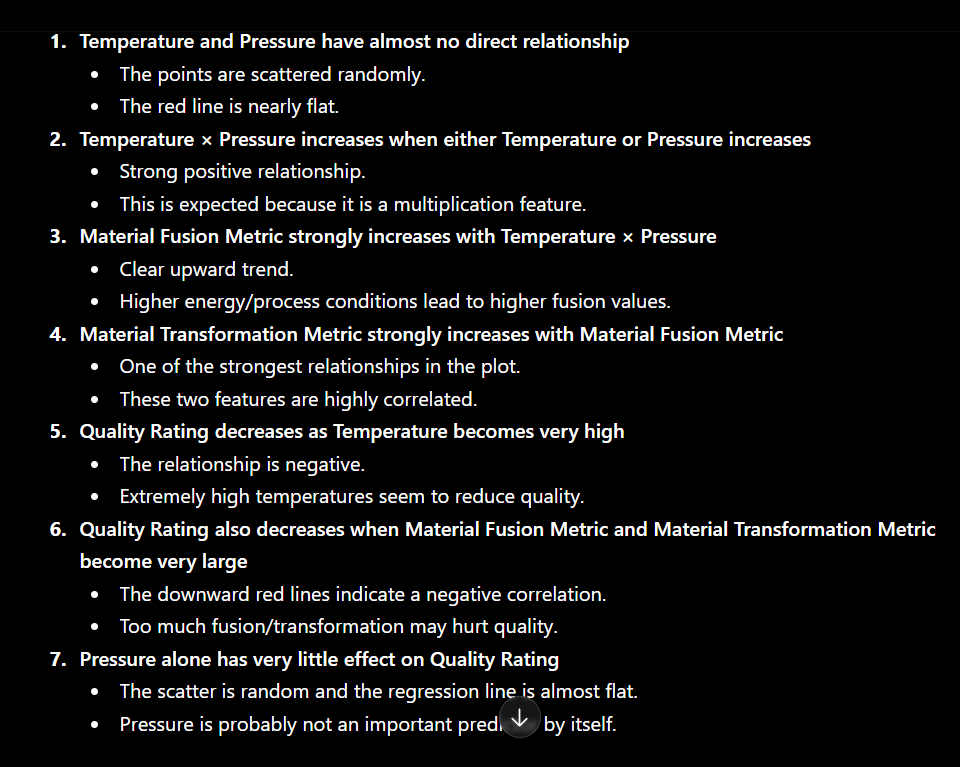

# Handling Outliers

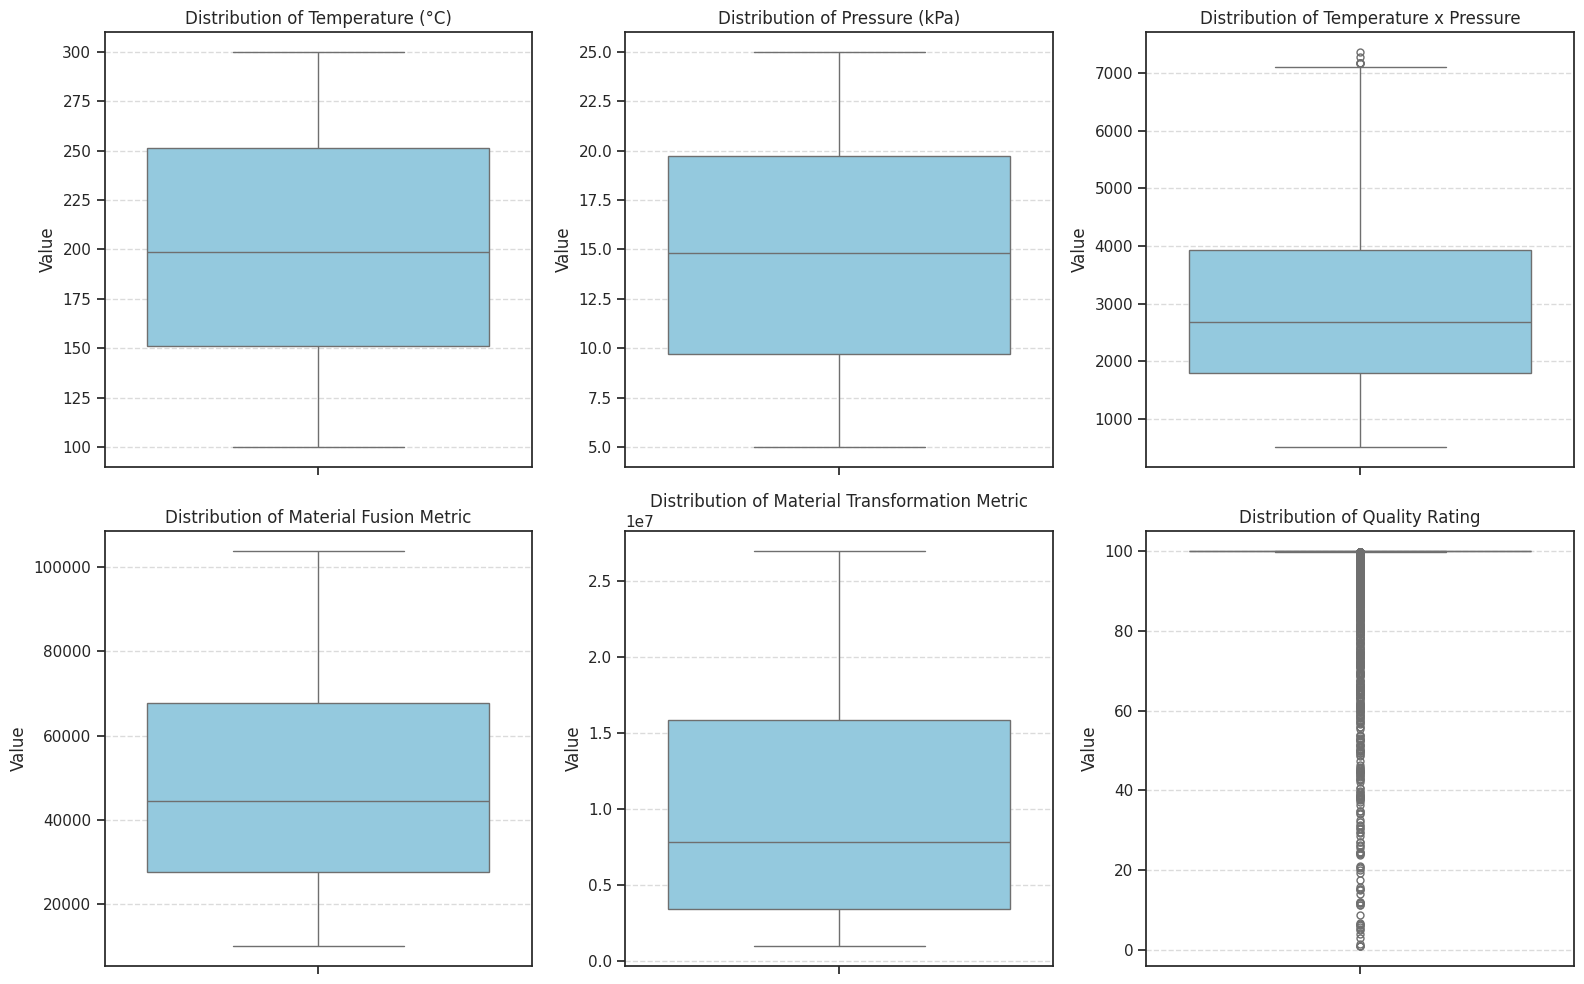

In [ ]:
# Select your 6 manufacturing features
features = df.select_dtypes(include=["number"]).columns[:6]

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten the 2D array to 1D for easy looping

# Plot each feature in its own subplot
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue", fliersize=5)
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_ylabel("Value")
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# Hide any unused subplots if you have fewer than 6 features
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

 > There is no outliers Among features

# seperate tar vs feature

In [ ]:
X = df.drop(columns=['Quality Rating'])
y=df['Quality Rating']

# Splitting dataset

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

                                                 X,y,
                                                 test_size= 0.3,
                                                 random_state= 42
)

# Generate Polynomial feature

In [ ]:
# 3. Generate Polynomial Features (Degree 2 captures curves perfectly)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scalling Features


Start
 └──

 Are you using Tree Models (Random Forest, XGBoost)?

      ├── YES ──> No scaling needed.
      └── NO
           └── Does your data have significant outliers?
                ├── YES ──> Use RobustScaler.
                └── NO
                     └── Do you need a strict bounded range (e.g., 0 to 1)?
                          ├── YES ──> Use MinMaxScaler.
                          └── NO  ──> Use StandardScaler (Safe Default).

 > There is no categorical feature so we dont need to encode any of columns

## apply scalling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.fit_transform(X_test_poly)


## convert into array

In [ ]:

X_train_scaled

array([[ 0.21291342, -1.57945638, -1.21385415, ..., -0.32495626,
        -0.31498888, -0.33677943],
       [-1.45142902, -0.16335215, -0.92664599, ..., -1.0474178 ,
        -0.90533333, -0.80414976],
       [ 1.18195525,  1.07132597,  1.87339838, ...,  1.50076754,
         1.31864121,  1.13052627],
       ...,
       [ 1.49572003, -0.80170294, -0.02437281, ...,  1.6281246 ,
         1.8723515 ,  2.06311432],
       [-1.00659077,  0.96083404, -0.03472141, ..., -0.82463425,
        -0.82389656, -0.77406444],
       [-0.09743777,  1.49469194,  1.12707488, ..., -0.1212158 ,
        -0.4044551 , -0.53374955]])

# Train LinearModel With Polynomial data

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train_scaled,y_train)

LinearRegression()

## make prediction

In [ ]:
y_pred = poly_model.predict(X_test_scaled)

# Evaluate the model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("--- Polynomial Regression Performance ---")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

--- Polynomial Regression Performance ---
R² Score: 0.8717
Mean Absolute Error (MAE): 3.5739
Root Mean Squared Error (RMSE): 5.0702


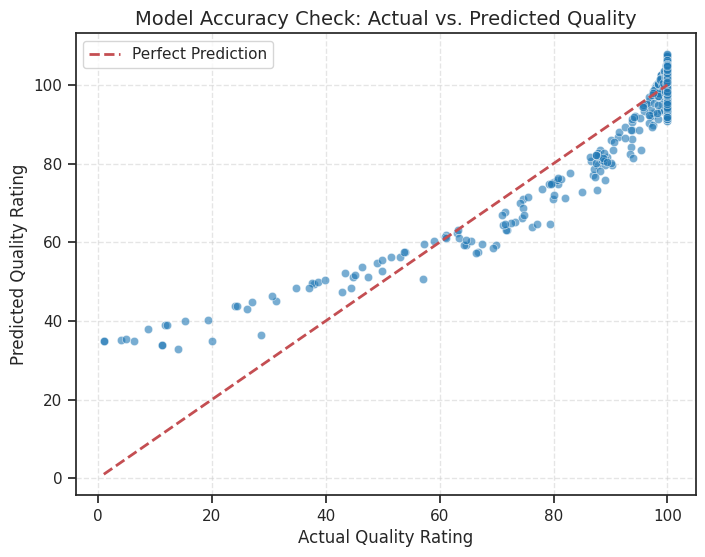

In [ ]:
plt.figure(figsize=(8, 6))

# Plot the predictions vs true values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="#1f77b4")

# Draw a perfect diagonal reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)

plt.title("Model Accuracy Check: Actual vs. Predicted Quality", fontsize=14)
plt.xlabel("Actual Quality Rating", fontsize=12)
plt.ylabel("Predicted Quality Rating", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

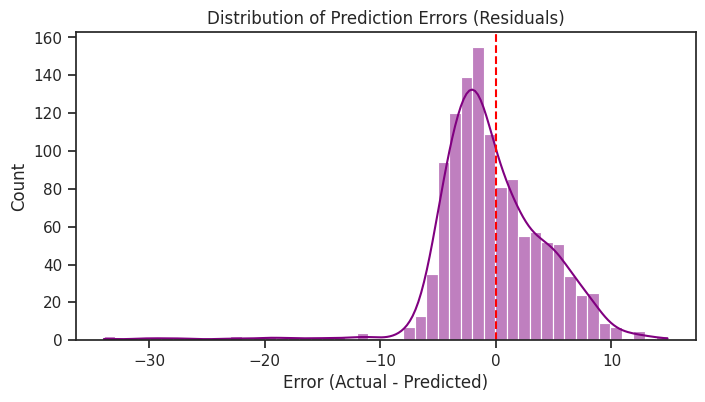

In [ ]:
# Calculate the errors (residuals)
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


# Final Findings

> Here Tree Based Model would give the best accuracy
our polynomial regression give 87% accuraxe